In [19]:
import lgdo
import lh5
import numpy as np
import awkward as ak
import os
import re

In [20]:
filepath = "/mnt/atlas02/users/leoli/scarf/sp01/data/hit_vcs"
files = os.listdir(filepath)
files.sort()
files

pnum_cal = "00"
run_cal = "037"

pnum_phy_bg = "00"
run_phy_bg = "038"

pnum_phy_signal = "05"
run_phy_signal = "059"

runs = [
    's20ns_mw5',  's20ns_mw7',
    's30ns_mw3',  's30ns_mw5',  's30ns_mw7',
    's40ns_mw1',  's40ns_mw3',  's40ns_mw5',  's40ns_mw7',
    's50ns_mw1',  's50ns_mw3',  's50ns_mw5',  's50ns_mw7',
    's100ns_mw1', 's100ns_mw3', 's100ns_mw5', 's100ns_mw7',
    's200ns_mw1', 's200ns_mw3', 's200ns_mw5', 's200ns_mw7',
    's60ns_mw1',  's60ns_mw3',  's60ns_mw5',  's60ns_mw7',
    's300ns_mw1', 's300ns_mw3', 's300ns_mw5', 's300ns_mw7','s300ns_mw15',
    's500ns_mw1', 's500ns_mw3', 's500ns_mw5', 's500ns_mw7','s500ns_mw15',
    's700ns_mw1', 's700ns_mw3', 's700ns_mw5', 's700ns_mw7','s700ns_mw15',
    's1000ns_mw1',  's1000ns_mw3',  's1000ns_mw5',  's1000ns_mw7','s1000ns_mw15',
    's2000ns_mw3',  's2000ns_mw5',  's2000ns_mw7',
]
def build_run_db(runs, filepath):
    db = {}
    missing = []

    for run in runs:
        m = re.match(r"s(\d+)ns_mw(\d+)", run)
        if not m:
            missing.append(f"{run}: invalid run name format")
            continue

        run_path = os.path.join(filepath, run)
        phy_bg_path = os.path.join(run_path, "phy", f"p{pnum_phy_bg}", f"r{run_phy_bg}")
        phy_signal_path = os.path.join(run_path, "phy", f"p{pnum_phy_signal}", f"r{run_phy_signal}")
        cal_path = os.path.join(run_path, "cal", f"p{pnum_cal}", f"r{run_cal}")

        missing_this_run = []

        if not os.path.exists(run_path):
            missing_this_run.append(f"run folder missing: {run_path}")
        if not os.path.exists(phy_bg_path):
            missing_this_run.append(f"phy_bg path missing: {phy_bg_path}")
        if not os.path.exists(phy_signal_path):
            missing_this_run.append(f"phy_signal path missing: {phy_signal_path}")
        if not os.path.exists(cal_path):
            missing_this_run.append(f"cal path missing: {cal_path}")

        if missing_this_run:
            missing.append(f"{run}\n  " + "\n  ".join(missing_this_run))
            continue

        phy_bg_files = sorted(os.listdir(phy_bg_path))
        phy_signal_files = sorted(os.listdir(phy_signal_path))
        cal_files = sorted(os.listdir(cal_path))

        db[run] = {
            "run": run,
            "interval": f"{m.group(1)}ns",
            "mw": f"mw{m.group(2)}",

            "phy_bg_path": phy_bg_path,
            "phy_signal_path": phy_signal_path,
            "cal_path": cal_path,

            "phy_bg_files": phy_bg_files,
            "phy_signal_files": phy_signal_files,
            "cal_files": cal_files,

            "phy_bg_pathlist": [os.path.join(phy_bg_path, f) for f in phy_bg_files],
            "phy_signal_pathlist": [os.path.join(phy_signal_path, f) for f in phy_signal_files],
            "cal_pathlist": [os.path.join(cal_path, f) for f in cal_files],
        }

    if missing:
        raise FileNotFoundError(
            "[ERROR] Some runs or paths are missing:\n\n" + "\n\n".join(missing)
        )

    return db
run_db = build_run_db(runs, filepath)

In [3]:
pathlist = 'cal_pathlist'

In [4]:
obj = lh5.read("ch002/hit",run_db['s100ns_mw5'][pathlist])

In [5]:
obj.view_as('pd')

,A_max_mw_o_E_Classifier,A_max_mw_o_E_Corrected,A_max_mw_o_E_Double_Sided_Cut,A_max_mw_o_E_High_Side_Cut,A_max_mw_o_E_Low_Cut,A_max_mw_o_E_Timecorr,A_max_mw_o_E_Uncorr,A_max_mw_o_E_fix_Classifier,A_max_mw_o_E_fix_Corrected,A_max_mw_o_E_fix_Double_Sided_Cut,...,is_valid_bl_slope_rms,is_valid_leading_edge,is_valid_tail,is_valid_tail_rms,is_valid_waveform,timestamp,trapEftp_cal,trapEftp_fix_cal,trapEmax_cal,trapEmax_fix_cal
0,-1.365062,0.989189,True,True,True,0.989274,0.511915,-1.370421,0.989195,True,...,True,True,True,True,True,1.698336e+09,1112.973833,1112.717149,1112.959307,1113.243801
1,-6.660824,0.942069,False,True,False,0.942403,0.487661,-6.836002,0.941520,False,...,True,True,True,True,True,1.698336e+09,1012.569995,1012.909620,1012.494815,1012.267336
2,3.258177,35.683356,False,False,True,35.792167,18.521201,8.104571,91.030622,False,...,True,False,True,True,False,1.698336e+09,5.132224,2.010784,5.489034,6.218318
3,NaN,-4.768997,False,False,False,-4.783679,-2.475388,NaN,-5.400979,False,...,True,True,True,True,True,1.698336e+09,-5.793166,-5.112766,0.980722,2.697431
4,4.409106,13.805490,False,False,True,13.847289,7.165491,10.004245,21.538532,False,...,True,False,True,True,False,1.698336e+09,13.215952,8.466709,14.229946,10.572384
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2292775,0.110859,195.300279,True,True,True,195.898433,101.370626,NaN,-42.494549,False,...,True,True,True,True,True,1.698417e+09,0.124789,-0.573230,0.477747,3.018641
2292776,NaN,-59.195580,False,False,False,-59.377043,-30.725554,1.885436,95.073877,True,...,True,True,True,True,True,1.698417e+09,-0.899229,0.559610,1.519771,1.940569
2292777,-0.654668,0.989305,True,True,True,0.990771,0.512689,-0.696097,0.989794,True,...,True,True,True,True,True,1.698417e+09,591.043857,590.543484,590.998233,590.587951
2292778,-3.249641,0.984033,False,True,False,0.980579,0.507415,-3.055857,0.984851,False,...,True,True,True,True,True,1.698417e+09,2456.970850,2455.173269,2456.953165,2455.558013


In [6]:
run = 's100ns_mw5'
pathlist = 'cal_pathlist'

In [7]:
E_1=lh5.read("ch002/hit/trapEftp_fix_cal",run_db[run][pathlist])
A_max_mw_o_E_Classifier_1=lh5.read("ch002/hit/A_max_mw_o_E_Classifier",run_db[run][pathlist])
Iasy_std = lh5.read("ch002/hit/Iasy",run_db['s100ns_mw5'][pathlist])
is_valid_waveform_1= lh5.read("ch002/hit/is_valid_waveform",run_db['s100ns_mw5'][pathlist])
low_cut_1 = lh5.read("ch002/hit/A_max_mw_o_E_fix_Low_Cut",run_db['s100ns_mw5'][pathlist])

In [8]:
E_1 = np.asarray(E_1)
# A_max_mw_o_E_High_Side_Cut_std = np.asarray(A_max_mw_o_E_High_Side_Cut_std)
Iasy_std = np.asarray(Iasy_std)
A_max_mw_o_E_Classifier_1= np.asarray(A_max_mw_o_E_Classifier_1)
is_valid_waveform_1 = np.asarray(is_valid_waveform_1)
low_cut_1 = np.asarray(low_cut_1)

In [9]:
run = 's200ns_mw7'

In [10]:
E_2=lh5.read("ch002/hit/trapEftp_fix_cal",run_db[run][pathlist])
A_max_mw_o_E_Classifier_2=lh5.read("ch002/hit/A_max_mw_o_E_Classifier",run_db[run][pathlist])
Iasy_std = lh5.read("ch002/hit/Iasy",run_db['s300ns_mw5'][pathlist])
is_valid_waveform_2 = lh5.read("ch002/hit/is_valid_waveform",run_db[run][pathlist])
low_cut_2 = lh5.read("ch002/hit/A_max_mw_o_E_Low_Cut",run_db[run][pathlist])

In [11]:
E_2 = np.asarray(E_2)
Iasy_std = np.asarray(Iasy_std)
A_max_mw_o_E_Classifier_2 = np.asarray(A_max_mw_o_E_Classifier_2)
is_valid_waveform_2 = np.asarray(is_valid_waveform_2)
low_cut_2 = np.asarray(low_cut_2)

In [12]:
comb_low_cut = low_cut_1 & low_cut_2
fwhm = 3.7840849039815585 
fwhm_err = 0.14498873542717602
DEP_mask_1 = (E_1 > 1592.53-2.33*fwhm) & (E_1<1592.53+2.33*fwhm)
DEP_mask_2 = (E_2 > 1592.53-2.33*fwhm) & (E_2<1592.53+2.33*fwhm)


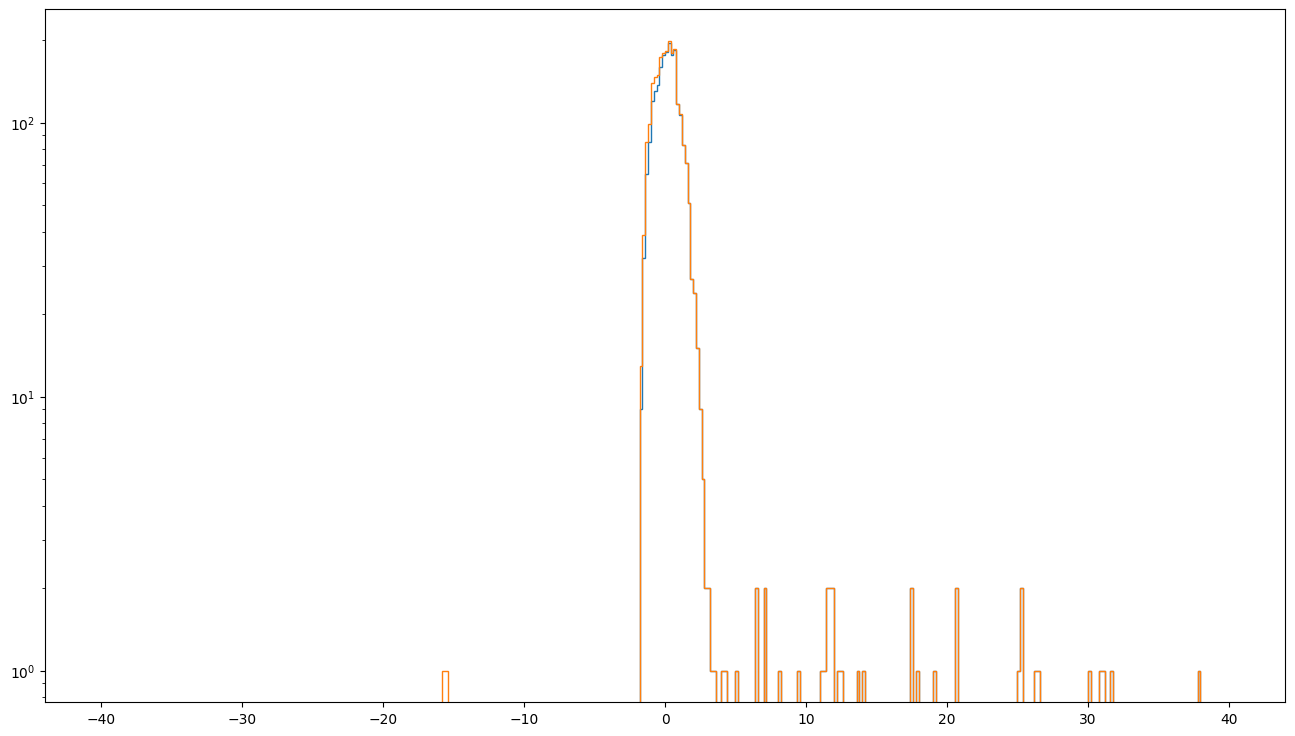

In [36]:
from matplotlib import pyplot as plt
nbins = 400; range = (-40,40)
fig,ax = plt.subplots(figsize=(16,9))
ax.set_yscale('log')
bins,edges,_ = ax.hist(A_max_mw_o_E_Classifier_1[comb_low_cut&is_valid_waveform_1&DEP_mask_1],range=range,bins=nbins,histtype='step')
bins_2,edges_2,_ = ax.hist(A_max_mw_o_E_Classifier_1[low_cut_1&is_valid_waveform_1&DEP_mask_1],range=range,bins=nbins,histtype='step')
# ax.hist(A_max_mw_o_E_Classifier_2[comb_low_cut&is_valid_waveform_2&DEP_mask_2],range=range,bins=nbins,histtype='step')
difference = bins - bins_2

# fig_2,ax_2 = plt.subplots(figsize=(16,9))
# ax_2.stairs(difference, edges, label="Difference",linestyle="--",color='red',linewidth=10)
# ax_2.axhline(0, color="black", linewidth=0.8)

In [14]:
n=0
for x in difference:
   n+=x
print(n) 

-123.0


In [15]:
import pickle

path = "/mnt/atlas02/users/leoli/SEP_analysis/sf_results_cut90_linear_interpolation_all_50points.pkl"

with open(path, "rb") as f:
    sf_results = pickle.load(f)

FileNotFoundError: [Errno 2] No such file or directory: '/mnt/atlas02/users/leoli/SEP_analysis/sf_results_cut90_linear_interpolation_all_50points.pkl'

In [ ]:
sf_results.keys()
# sf_results['cut_value_90']

dict_keys(['meta', 'cut_value_90', 'cut_value_90_err', 'dep_sfs', 'sep_sfs', 'fep_sfs'])

In [ ]:
cut_1 = sf_results['cut_value_90']['s100ns_mw5']
cut_2 = sf_results['cut_value_90']['s200ns_mw5']

In [ ]:
print(f"Cut 1: {cut_1}, Cut 2: {cut_2}")

Cut 1: -1.6929142468222862, Cut 2: -1.5839769324901296


In [17]:
aoe_field = 'A_max_mw_o_E_fix_Classifier'
low_cut_field = 'A_max_mw_o_E_fix_Low_Cut'
energy_field = 'trapEftp_fix_cal'
energy_array = np.asarray(lh5.read("ch002/hit",run_db[run]['cal_pathlist'])[energy_field])
aoe_array = np.asarray(lh5.read("ch002/hit",run_db[run]['cal_pathlist'])[aoe_field])
is_valid_waveform= np.asarray(lh5.read("ch002/hit",run_db[run]['cal_pathlist'])['is_valid_waveform'])


In [18]:

fitrange_dep = (1565, 1615)
peak_dep = 1592.5

mask_dep = (
    np.isfinite(energy_array)
    & np.isfinite(aoe_array)
    & (energy_array > fitrange_dep[0])
    & (energy_array < fitrange_dep[1])
    & is_valid_waveform)

E_fit_dep = energy_array[mask_dep]
aoe_fit_dep = aoe_array[mask_dep]

print("E_fit_dep:", len(E_fit_dep))
print("aoe_fit_dep:", len(aoe_fit_dep))


fitrange_sep = (2070, 2140)

peak_sep =2103.5


mask_sep = (
    np.isfinite(energy_array)
    & np.isfinite(aoe_array)
    & (energy_array > fitrange_sep[0])
    & (energy_array < fitrange_sep[1])
    & is_valid_waveform
)

E_fit_sep = energy_array[mask_sep]
aoe_fit_sep = aoe_array[mask_sep]

fitrange_fep =  (2580, 2645)
peak_fep = 2614.5
mask_fep = (
    np.isfinite(energy_array)
    & np.isfinite(aoe_array)
    & (energy_array > fitrange_fep[0])
    & (energy_array < fitrange_fep[1])
    & is_valid_waveform
)
E_fit_fep = energy_array[mask_fep]
aoe_fit_fep = aoe_array[mask_fep] 


E_fit_dep: 9144
aoe_fit_dep: 9144


In [34]:
import pygama.pargen.survival_fractions as sf
survival_fractions = {}
for run in runs:
    cut_value = sf_results['cut_value_90'][run]
    cut_error = sf_results['cut_value_90_err'][run]
    print(f"Run {run}: cut_value_90 = {cut_value:.6f} with a sf err of {cut_error:.6f}")
    sf_val_dep, sf_err_dep, values_dep, errors_dep = sf.get_survival_fraction(
        energy=E_fit_dep,
        cut_param=aoe_fit_dep,
        cut_val=cut_value,
        peak=peak_dep,        # DEP peak
        fit_range=fitrange_dep,
        func=sf.hpge_peak,
        mode="greater",
        display=1,
        eres_pars=3
    )
    print("survival fraction dep =", sf_val_dep)
    print("survival fraction error =", sf_err_dep)

    sf_val_sep, sf_err_sep, values_sep, errors_sep = sf.get_survival_fraction(
        energy=E_fit_sep,
        cut_param=aoe_fit_sep,
        cut_val=cut_value,      
        peak=peak_sep,        # SEP peak
        fit_range=fitrange_sep,
        func=sf.hpge_peak,
        mode="greater",
        display=1,
        eres_pars=3
    )
    print("survival fraction sep=", sf_val_sep)
    print("survival fraction error =", sf_err_sep) 

    sf_val_fep, sf_err_fep, values_fep, errors_fep = sf.get_survival_fraction(
        energy=E_fit_fep,
        cut_param=aoe_fit_fep,
        cut_val=cut_value,      
        peak=peak_fep,        # FEP peak
        fit_range=fitrange_fep,
        func=sf.hpge_peak,
        mode="greater",
        display=1,
        eres_pars=3
    )
    print("survival fraction fep=", sf_val_fep)
    print("survival fraction error =", sf_err_fep)    
    survival_fractions[run] = {
        'cut_value_90': cut_value,
        'cut_value_90_err': cut_error,
        'sf_dep': sf_val_dep,
        'sf_dep_err': sf_err_dep,
        'sf_sep': sf_val_sep,
        'sf_sep_err': sf_err_sep,
        'sf_fep': sf_val_fep,
        'sf_fep_err': sf_err_fep
    }

KeyError: 'cut_value_90'

In [ ]:
import pickle
from pathlib import Path
outpath = Path("survival_fractions.pkl")

with open(outpath, "wb") as f:
    pickle.dump(survival_fractions, f)

print("saved to:", outpath.resolve())

saved to: /mnt/atlas02/users/leoli/AoverE_analysis/both_sided_cuts/survival_fractions.pkl


In [31]:
import pickle
with open("/mnt/atlas02/users/leoli/AoverE_analysis/SEP_analysis/survival_db_yaml.pkl", "rb") as f:
    sf_results = pickle.load(f)
sf_results["s1000ns_mw1"].keys()

dict_keys(['cut_value_90', 'dep_sf', 'sep_sf', 'fep_sf', 'dep_sf_err', 'sep_sf_err', 'fep_sf_err'])

In [20]:
def plot_heatmap(sf_results):
    for run in runs:
        cut_value = sf_results['cut_value_90'][run]
        cut_error = sf_results['cut_value_90_err'][run]
        print(f"Run {run}: cut_value_90 = {cut_value:.6f} with a sf err of {cut_error:.6f}")
    pass


In [32]:
def two_cut_sf(run1,run2):
    ## masks for dep sep fep
    fitrange_dep = (1565, 1615)
    peak_dep = 1592.5
    energy_array = np.asarray(lh5.read("ch002/hit/trapEftp_fix_cal",run_db[run2]['cal_pathlist']))
    aoe_array = np.asarray(lh5.read("ch002/hit/A_max_mw_o_E_fix_Classifier",run_db[run2]['cal_pathlist']))
    is_valid_waveform= lh5.read("ch002/hit/is_valid_waveform",run_db['s100ns_mw5'][pathlist])

    # run1 
    E_1=lh5.read("ch002/hit/trapEftp_fix_cal",run_db[run1][pathlist])
    Iasy_std = lh5.read("ch002/hit/Iasy",run_db["s100ns_mw5"][pathlist])
    low_cut_1 = lh5.read("ch002/hit/A_max_mw_o_E_fix_Low_Cut",run_db[run1][pathlist])
    A_max_mw_o_E_Classifier_1=lh5.read("ch002/hit/A_max_mw_o_E_fix_Classifier",run_db[run1][pathlist])
    E_1 = np.asarray(E_1)
    # A_max_mw_o_E_High_Side_Cut_std = np.asarray(A_max_mw_o_E_High_Side_Cut_std)
    Iasy_std = np.asarray(Iasy_std)
    A_max_mw_o_E_Classifier_1= np.asarray(A_max_mw_o_E_Classifier_1)
    is_valid_waveform = np.asarray(is_valid_waveform)
    low_cut_1 = np.asarray(low_cut_1)
    
    # run2
    # E_2=lh5.read("ch002/hit/trapEftp_fix_cal",run_db[run2][pathlist])
    # low_cut_2 = lh5.read("ch002/hit/A_max_mw_o_E_Low_Cut",run_db[run2][pathlist])
    # comb_low_cut = low_cut_1 & low_cut_2
    cut_value = sf_results[run2]['cut_value_90']
    mask_dep = (
        np.isfinite(energy_array)
        & np.isfinite(aoe_array)
        & (energy_array > fitrange_dep[0])
        & (energy_array < fitrange_dep[1])
        & is_valid_waveform
        & low_cut_1)

    E_fit_dep = energy_array[mask_dep]
    aoe_fit_dep = aoe_array[mask_dep]

    # fitrange_sep = (2070, 2140)

    # peak_sep =2103.5

    # mask_sep = (
    #     np.isfinite(energy_array)
    #     & np.isfinite(aoe_array)
    #     & (energy_array > fitrange_sep[0])
    #     & (energy_array < fitrange_sep[1])
    #     & is_valid_waveform
    # )

    # E_fit_sep = energy_array[mask_sep]
    # aoe_fit_sep = aoe_array[mask_sep]

    # fitrange_fep =  (2580, 2645)
    # peak_fep = 2614.5
    # mask_fep = (
    #     np.isfinite(energy_array)
    #     & np.isfinite(aoe_array)
    #     & (energy_array > fitrange_fep[0])
    #     & (energy_array < fitrange_fep[1])
    #     & is_valid_waveform
    # )
    # E_fit_fep = energy_array[mask_fep]
    # aoe_fit_fep = aoe_array[mask_fep] 
    ## aoe field read
    # aoe_field = 'A_max_mw_o_E_fix_Classifier'
    # low_cut_field = 'A_max_mw_o_E_fix_Low_Cut'
    # energy_field = 'trapEftp_fix_cal'
    
    sf_val_dep, sf_err_dep, values_dep, errors_dep = sf.get_survival_fraction(
            energy=E_fit_dep,
            cut_param=aoe_fit_dep,
            cut_val=cut_value,
            peak=peak_dep,        # DEP peak
            fit_range=fitrange_dep,
            func=sf.hpge_peak,
            mode="greater",
            display=1,
            eres_pars=3
        )
    return sf_val_dep, sf_err_dep, run1, run2


In [22]:
from itertools import product
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sf_correlations = {}

for run1, run2 in product(runs, repeat=2):
    sf_val_dep, sf_err_dep, *_ = two_cut_sf(run1, run2)

    sf_correlations[(run1, run2)] = (
        float(sf_val_dep),
        float(sf_err_dep),
    )

NameError: name 'two_cut_sf' is not defined

In [41]:
n_runs = len(runs)

sf_values = np.empty((n_runs, n_runs))
sf_errors = np.empty((n_runs, n_runs), dtype=float)
annotations = np.empty((n_runs, n_runs), dtype=object)

for i, run1 in enumerate(runs):
    for j, run2 in enumerate(runs):
        value, error = sf_correlations[(run1, run2)]

        sf_values[i, j] = value
        sf_errors[i, j] = error
        annotations[i, j] = f"{value:.2f}\n± {error:.3f}"

In [42]:
import pickle
from pathlib import Path
outpath = Path("survival_correlations.pkl")

with open(outpath, "wb") as f:
    pickle.dump(sf_correlations, f)

print("saved to:", outpath.resolve())

sf_correlations

saved to: /mnt/atlas02/users/leoli/AoverE_analysis/two_aoe_cuts/survival_correlations.pkl


{('s20ns_mw5', 's20ns_mw5'): (85.47166594921669, 1.2601850712062712),
 ('s20ns_mw5', 's20ns_mw7'): (90.10554639205876, 1.1184340727213082),
 ('s20ns_mw5', 's30ns_mw3'): (90.99870355854821, 1.0780617265087333),
 ('s20ns_mw5', 's30ns_mw5'): (93.38611767097834, 1.006347532581331),
 ('s20ns_mw5', 's30ns_mw7'): (93.57083719788127, 1.011763608037658),
 ('s20ns_mw5', 's40ns_mw1'): (91.58413628201077, 1.038871507874134),
 ('s20ns_mw5', 's40ns_mw3'): (94.20000366795426, 0.9703868742659882),
 ('s20ns_mw5', 's40ns_mw5'): (93.12465165528192, 1.0429784979107848),
 ('s20ns_mw5', 's40ns_mw7'): (92.1316157817053, 1.0953913112317692),
 ('s20ns_mw5', 's50ns_mw1'): (88.5166649742038, 1.1882793524095547),
 ('s20ns_mw5', 's50ns_mw3'): (93.43703450992695, 1.0313091019488907),
 ('s20ns_mw5', 's50ns_mw5'): (91.06998784630213, 1.1354318328276047),
 ('s20ns_mw5', 's50ns_mw7'): (90.86756138490118, 1.1492547834044686),
 ('s20ns_mw5', 's100ns_mw1'): (92.44377046898545, 1.065341855915053),
 ('s20ns_mw5', 's100ns_mw

In [ ]:
fig, ax = plt.subplots(figsize=(120, 100))

sns.heatmap(
    sf_values,
    annot=annotations,
    fmt="",
    xticklabels=runs,
    yticklabels=runs,
    cmap="viridis",
    square=True,
    ax=ax,
    cbar_kws={"label": "SF value"},
)

ax.set_xlabel("run2")
ax.set_ylabel("run1")
ax.set_title("Survival-fraction correlations")

plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [37]:
sf_correlations

{('s20ns_mw5', 's20ns_mw5'): (85.47166594921669, 1.2601850712062712),
 ('s20ns_mw5', 's20ns_mw7'): (90.10554639205876, 1.1184340727213082),
 ('s20ns_mw5', 's30ns_mw3'): (90.99870355854821, 1.0780617265087333),
 ('s20ns_mw5', 's30ns_mw5'): (93.38611767097834, 1.006347532581331),
 ('s20ns_mw5', 's30ns_mw7'): (93.57083719788127, 1.011763608037658),
 ('s20ns_mw5', 's40ns_mw1'): (91.58413628201077, 1.038871507874134),
 ('s20ns_mw5', 's40ns_mw3'): (94.20000366795426, 0.9703868742659882),
 ('s20ns_mw5', 's40ns_mw5'): (93.12465165528192, 1.0429784979107848),
 ('s20ns_mw5', 's40ns_mw7'): (92.1316157817053, 1.0953913112317692),
 ('s20ns_mw5', 's50ns_mw1'): (88.5166649742038, 1.1882793524095547),
 ('s20ns_mw5', 's50ns_mw3'): (93.43703450992695, 1.0313091019488907),
 ('s20ns_mw5', 's50ns_mw5'): (91.06998784630213, 1.1354318328276047),
 ('s20ns_mw5', 's50ns_mw7'): (90.86756138490118, 1.1492547834044686),
 ('s20ns_mw5', 's100ns_mw1'): (92.44377046898545, 1.065341855915053),
 ('s20ns_mw5', 's100ns_mw

In [34]:
import pickle 
with open("/mnt/atlas02/users/leoli/AoverE_analysis/two_aoe_cuts/survival_correlations.pkl","rb") as f:
    sf_corr=pickle.load(f)

In [28]:
from pprint import pprint

pprint(sf_corr)

{('s1000ns_mw1', 's1000ns_mw1'): (86.64946842656961, 0.6087245916024453),
 ('s1000ns_mw1', 's1000ns_mw15'): (75.89646920750782, 1.233113380463467),
 ('s1000ns_mw1', 's1000ns_mw3'): (78.86585903837681, 1.2815378988211086),
 ('s1000ns_mw1', 's1000ns_mw5'): (78.524167159451, 1.2724112695287477),
 ('s1000ns_mw1', 's1000ns_mw7'): (79.00807044016776, 1.23155982596032),
 ('s1000ns_mw1', 's100ns_mw1'): (78.23527470517458, 1.4060591691291497),
 ('s1000ns_mw1', 's100ns_mw3'): (76.73538517390857, 1.4434946107744635),
 ('s1000ns_mw1', 's100ns_mw5'): (76.71778315837695, 1.4383915856189788),
 ('s1000ns_mw1', 's100ns_mw7'): (76.87331627537276, 1.4386465871305953),
 ('s1000ns_mw1', 's2000ns_mw3'): (78.96260509258171, 1.1793159635357604),
 ('s1000ns_mw1', 's2000ns_mw5'): (78.64760345714231, 1.1987658457739525),
 ('s1000ns_mw1', 's2000ns_mw7'): (76.65459855046477, 1.2102785383561931),
 ('s1000ns_mw1', 's200ns_mw1'): (73.145914224387, 1.468335058602433),
 ('s1000ns_mw1', 's200ns_mw3'): (76.93307970617477

In [32]:
for key in sf_corr:
    sf_corr[key] = (sf_corr[key][0] * 0.9, *sf_corr[key][1:])

In [35]:
from itertools import product
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

n_runs = len(runs)

sf_values = np.empty((n_runs, n_runs))
sf_errors = np.empty((n_runs, n_runs), dtype=float)
annotations = np.empty((n_runs, n_runs), dtype=object)

for i, run1 in enumerate(runs):
    for j, run2 in enumerate(runs):
        value, error = sf_corr[(run1, run2)]

        sf_values[i, j] = value
        sf_errors[i, j] = error
        annotations[i, j] = f"{value:.2f}\n± {error:.3f}"

fig, ax = plt.subplots(figsize=(120, 100))

sns.heatmap(
    sf_values,
    annot=annotations,
    fmt="",
    xticklabels=runs,
    yticklabels=runs,
    cmap="viridis",
    square=True,
    ax=ax,
    cbar_kws={"label": "SF value"},
)

ax.set_xlabel("run2")
ax.set_ylabel("run1")
ax.set_title("Survival-fraction correlations")

plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()